In [43]:
import os
from dotenv import load_dotenv
ROOT = "../" # Base directory relative to this notebook's location. Adjust if the notebook is moved
CSV_DIR = os.path.join(ROOT, "csv")
DOTENV_PATH = os.path.join(ROOT, '../../apis/.env') # Adjust to .env file location
if load_dotenv(DOTENV_PATH):
    abs_path = os.path.abspath(DOTENV_PATH)
    drive, rel = os.path.splitdrive(abs_path)
    parts = rel.strip(os.sep).split(os.sep)
    masked = parts.copy()
    masked_parts = 1  # adjust to mask parts of your path
    max_maskable = max(0, len(parts) - 2)
    for i in range(min(masked_parts, max_maskable)):
        idx = len(parts) - 3 - i
        masked[idx] = "***"
    prefix = f"{drive}{os.sep}" if drive else (os.sep if abs_path.startswith(os.sep) else "")
    print(f"Loaded .env from {prefix}{os.sep.join(masked)}")
else:
    print("Failed to load .env file.")

API_KEY = os.getenv("AEMET_API_KEY")

def mask_token(token, unmasked_chars=3):
    return token[:unmasked_chars] + '*' * (len(token) - unmasked_chars*2) + token[-unmasked_chars:]
print(f"AEMET_API_KEY: {mask_token(API_KEY)}")

# Variables de ejecución avanzadas (no es necesario cambiarlas si no se ha alterado la estructura de ficheros del proyecto):
DB_FILE = "db/thematic_screener.db" # Sólo necesario si DOWNLOAD_REMOTE_DB = False
import sys
sys.path.append(ROOT)

from src.aemet_helpers import AemetClient
import random
from datetime import datetime
import pandas as pd
import time
import matplotlib.pyplot as plt

Loaded .env from c:\Users\david\***\apis\.env
AEMET_API_KEY: eyJ***********************************************************************************************************************************************************************************************************************************************************************************************************rF4


### Querying up to 6 months

In [19]:
client = AemetClient(API_KEY)
station_id = "0367"
start_date = "2021-01-01"
n_dias = 180  # each query supports approximately 6 months of data
end_date = (datetime.strptime(start_date, "%Y-%m-%d") + pd.Timedelta(days=n_dias)).strftime("%Y-%m-%d")
data = pd.DataFrame(client.fetch_station_history(station_id, start_date, end_date))
display(data.head(5))
print("...")
display(data.tail(5))
last_date = pd.to_datetime(data['fecha']).iloc[-1]
print(last_date)

,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,sol,presMax,horaPresMax,presMin,horaPresMin,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
0,2021-01-01,0367,GIRONA AEROPUERTO,GIRONA,143,"5,0","0,0","0,2",05:05,"9,8",...,"0,7","990,0",Varias,"987,5",14,71,97,Varias,49,15:47
1,2021-01-02,0367,GIRONA AEROPUERTO,GIRONA,143,"2,6","0,0","-2,0",Varias,"7,3",...,"0,0","992,7",Varias,"988,0",05,82,98,Varias,64,17:13
2,2021-01-03,0367,GIRONA AEROPUERTO,GIRONA,143,"2,7","0,0","-3,7",23:45,"9,1",...,"7,7","995,1",Varias,"992,5",00,70,94,Varias,43,12:17
3,2021-01-04,0367,GIRONA AEROPUERTO,GIRONA,143,"2,6","0,0","-4,9",Varias,"10,0",...,"7,8","994,7",00,"990,5",14,75,97,Varias,43,14:26
4,2021-01-05,0367,GIRONA AEROPUERTO,GIRONA,143,"3,8","0,0","-1,7",Varias,"9,2",...,"6,4","996,3",Varias,"992,7",04,71,97,Varias,44,12:56


...


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,sol,presMax,horaPresMax,presMin,horaPresMin,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
176,2021-06-26,0367,GIRONA AEROPUERTO,GIRONA,143,"23,6","0,0","15,5",02:22,"31,7",...,"11,3","1002,7",00,"996,7",18,51,96,Varias,33,14:27
177,2021-06-27,0367,GIRONA AEROPUERTO,GIRONA,143,"24,8","0,0","17,8",23:53,"31,8",...,"12,7","998,3",01,"996,0",17,41,77,Varias,17,11:06
178,2021-06-28,0367,GIRONA AEROPUERTO,GIRONA,143,"23,0","0,0","15,5",02:58,"30,6",...,"9,0","1000,3",Varias,"996,6",14,60,82,Varias,33,11:51
179,2021-06-29,0367,GIRONA AEROPUERTO,GIRONA,143,"21,4","0,0","14,4",04:01,"28,4",...,"8,2","1002,7",Varias,"999,8",03,61,89,04:37,45,11:31
180,2021-06-30,0367,GIRONA AEROPUERTO,GIRONA,143,"22,0","0,0","16,6",04:25,"27,4",...,"10,1","1002,9",Varias,"1000,5",17,57,91,Varias,48,11:54


2021-06-30 00:00:00


### Retrieving 6+ months of historical data

In [47]:
def download_station_data(station_id, start_date, max_retries=5, sleep_seconds=5):
    """
    Downloads weather station data from a given start date until current date.
    Queries data in 180-day batches and concatenates results.
    
    Args:
        station_id: AEMET station ID (e.g., "0367")
        start_date: Start date as string (format: "YYYY-MM-DD")
        max_retries: Number of retries for failed queries (default: 3)
        sleep_seconds: Seconds to sleep between queries (default: 2)
    
    Returns:
        DataFrame with all retrieved data, deduplicated by 'fecha'
    """
    all_data = pd.DataFrame()
    current_start = start_date
    n_dias = 180
    
    while True:
        # Calculate end date (180 days from current start)
        end_date = (pd.to_datetime(current_start) + pd.Timedelta(days=n_dias)).strftime("%Y-%m-%d")
        
        # Try to fetch with retries
        retries = 0
        data_batch = None
        
        while retries < max_retries:
            try:
                print(f"Fetching data for station {station_id} from {current_start} to {end_date}...")
                data_batch = pd.DataFrame(client.fetch_station_history(station_id, current_start, end_date))
                
                if len(data_batch) > 0:
                    first_date = data_batch['fecha'].iloc[0]
                    last_date = data_batch['fecha'].iloc[-1]
                    print(f"✓ Retrieved {len(data_batch)} records (from {first_date} to {last_date})")
                else:
                    print(f"✓ Retrieved 0 records")
                break
                
            except Exception as e:
                retries += 1
                print(f"✗ Error: {str(e)} (Retry {retries}/{max_retries})")
                if retries < max_retries:
                    time.sleep(sleep_seconds)
        
        # If all retries failed, exit
        if data_batch is None:
            print(f"Failed to retrieve data after {max_retries} retries. Stopping.")
            break
        
        # If no data retrieved, we've reached the end
        if len(data_batch) == 0:
            print("No more data available. Stopping.")
            break
        
        # Append batch to all_data
        all_data = pd.concat([all_data, data_batch], ignore_index=True)
        
        # Check if we got less data than expected (indicates we've reached current date)
        #if len(data_batch) < (n_dias + 1):
        #    print("Less data than expected. Likely reached current date. Stopping.")
        #    break
        
        # Update start date for next query (next day after last retrieved date)
        last_fecha = pd.to_datetime(data_batch['fecha'].iloc[-1])
        current_start = (last_fecha + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
        
        # Sleep before next query
        time.sleep(sleep_seconds)
    
    # Remove duplicates based on 'fecha'
    if len(all_data) > 0:
        initial_count = len(all_data)
        all_data = all_data.drop_duplicates(subset=['fecha'], keep='first')
        duplicates_removed = initial_count - len(all_data)
        if duplicates_removed > 0:
            print(f"\nRemoved {duplicates_removed} duplicate records")
        print(f"\nFinal dataset: {len(all_data)} records")
    
    return all_data.reset_index(drop=True)

In [26]:
df = download_station_data(station_id="0367", start_date="2021-01-01", max_retries=5, sleep_seconds=3)

Fetching data for station 0367 from 2021-01-01 to 2021-06-30...
✓ Retrieved 181 records (from 2021-01-01 to 2021-06-30)
Fetching data for station 0367 from 2021-07-01 to 2021-12-28...
✓ Retrieved 181 records (from 2021-07-01 to 2021-12-28)
Fetching data for station 0367 from 2021-12-29 to 2022-06-27...
✓ Retrieved 181 records (from 2021-12-29 to 2022-06-27)
Fetching data for station 0367 from 2022-06-28 to 2022-12-25...
✓ Retrieved 181 records (from 2022-06-28 to 2022-12-25)
Fetching data for station 0367 from 2022-12-26 to 2023-06-24...
✓ Retrieved 181 records (from 2022-12-26 to 2023-06-24)
Fetching data for station 0367 from 2023-06-25 to 2023-12-22...
✓ Retrieved 181 records (from 2023-06-25 to 2023-12-22)
Fetching data for station 0367 from 2023-12-23 to 2024-06-20...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2023-12-23T00:00:00UTC/fechafin/2024-06-20T00:00:00UTC/estacion/0367 (Retry 1

In [36]:
display(df.head(3))
print("...")
display(df.tail(3))

,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,sol,presMax,horaPresMax,presMin,horaPresMin,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
0,2021-01-01,0367,GIRONA AEROPUERTO,GIRONA,143,"5,0","0,0","0,2",05:05,"9,8",...,"0,7","990,0",Varias,"987,5",14,71,97,Varias,49,15:47
1,2021-01-02,0367,GIRONA AEROPUERTO,GIRONA,143,"2,6","0,0","-2,0",Varias,"7,3",...,"0,0","992,7",Varias,"988,0",05,82,98,Varias,64,17:13
2,2021-01-03,0367,GIRONA AEROPUERTO,GIRONA,143,"2,7","0,0","-3,7",23:45,"9,1",...,"7,7","995,1",Varias,"992,5",00,70,94,Varias,43,12:17


...


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,sol,presMax,horaPresMax,presMin,horaPresMin,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
1943,2026-04-28,0367,GIRONA AEROPUERTO,GIRONA,143,"18,2","0,0","10,9",04:40,"25,5",...,"12,2","1000,4",00,"996,0",16,65,98,Varias,40,14:09
1944,2026-04-29,0367,GIRONA AEROPUERTO,GIRONA,143,"19,0","0,0","13,5",04:17,"24,5",...,NaN,"999,5",Varias,"996,4",06,66,98,Varias,30,15:58
1945,2026-04-30,0367,GIRONA AEROPUERTO,GIRONA,143,"17,5","2,2","12,8",04:49,"22,2",...,"5,4","1004,8",Varias,"999,0",02,78,99,Varias,64,17:23


### Casting column formats

In [38]:
df.columns
print("\nColumn types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")


Column types:
fecha: object
indicativo: object
nombre: object
provincia: object
altitud: object
tmed: object
prec: object
tmin: object
horatmin: object
tmax: object
horatmax: object
dir: object
velmedia: object
racha: object
horaracha: object
sol: object
presMax: object
horaPresMax: object
presMin: object
horaPresMin: object
hrMedia: object
hrMax: object
horaHrMax: object
hrMin: object
horaHrMin: object


In [39]:
date_cols = ["fecha"]
text_cols = ["indicativo", "nombre", "provincia"]
int_cols = ["altitud", "dir", "hrMedia", "hrMax", "hrMin"]
float_cols = ["tmed", "prec", "tmin", "tmax", "velmedia", "racha", "sol", "presMax", "presMin"]
time_cols = ["horatmin", "horatmax", "horaracha", "horaPresMax", "horaPresMin", "horaHrMax", "horaHrMin"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d", errors="coerce")

for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

for col in int_cols:
    df[col] = (
        pd.to_numeric(df[col].astype("string").str.replace(",", ".", regex=False), errors="coerce")
        .astype("Int64")
    )

for col in float_cols:
    df[col] = pd.to_numeric(df[col].astype("string").str.replace(",", ".", regex=False), errors="coerce")

for col in time_cols:
    df[col] = df[col].astype("string").str.strip()

In [41]:
df.columns
print("\nColumn types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")


Column types:
fecha: datetime64[ns]
indicativo: string
nombre: string
provincia: string
altitud: Int64
tmed: Float64
prec: Float64
tmin: Float64
horatmin: string
tmax: Float64
horatmax: string
dir: Int64
velmedia: Float64
racha: Float64
horaracha: string
sol: Float64
presMax: Float64
horaPresMax: string
presMin: Float64
horaPresMin: string
hrMedia: Int64
hrMax: Int64
horaHrMax: string
hrMin: Int64
horaHrMin: string


In [42]:
df.to_csv(os.path.join(CSV_DIR,"hist_0367_from_2021.csv"), index=False)

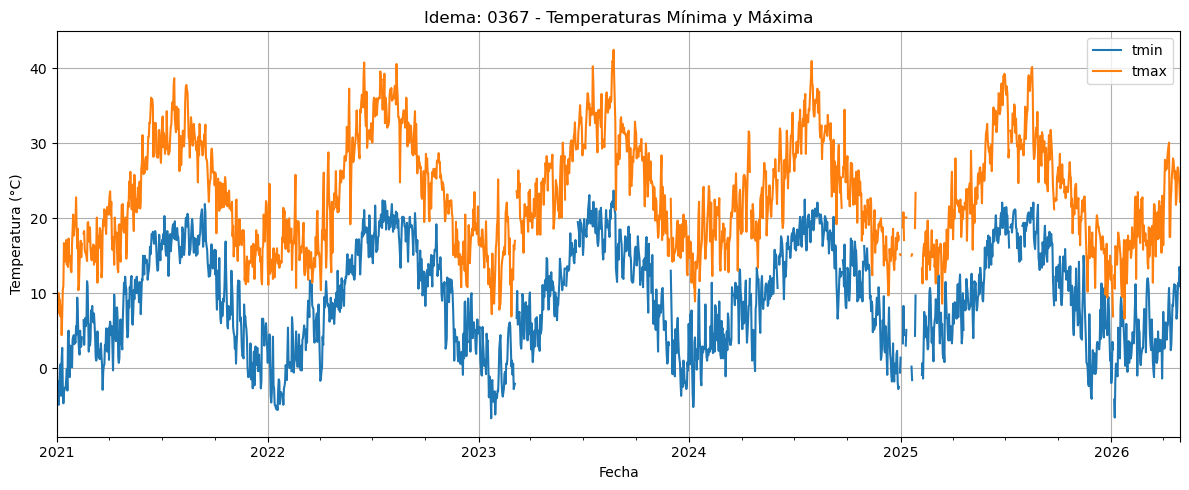

In [45]:
ax = df.sort_values("fecha").plot(x="fecha", y=["tmin", "tmax"], kind="line", figsize=(12,5))
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.set_title(f"Idema: {station_id} - Temperaturas Mínima y Máxima")
ax.grid(True)
plt.tight_layout()
plt.show()

### Testing a second location

In [48]:
data_9069C = download_station_data(station_id="9069C", start_date="2021-01-01", max_retries=5, sleep_seconds=3)

Fetching data for station 9069C from 2021-01-01 to 2021-06-30...
✓ Retrieved 171 records (from 2021-01-01 to 2021-06-30)
Fetching data for station 9069C from 2021-07-01 to 2021-12-28...
✓ Retrieved 181 records (from 2021-07-01 to 2021-12-28)
Fetching data for station 9069C from 2021-12-29 to 2022-06-27...
✓ Retrieved 181 records (from 2021-12-29 to 2022-06-27)
Fetching data for station 9069C from 2022-06-28 to 2022-12-25...
✓ Retrieved 181 records (from 2022-06-28 to 2022-12-25)
Fetching data for station 9069C from 2022-12-26 to 2023-06-24...
✓ Retrieved 181 records (from 2022-12-26 to 2023-06-24)
Fetching data for station 9069C from 2023-06-25 to 2023-12-22...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2023-06-25T00:00:00UTC/fechafin/2023-12-22T00:00:00UTC/estacion/9069C (Retry 1/5)
Fetching data for station 9069C from 2023-06-25 to 2023-12-22...
✗ Error: 429 Client Error: Too Many Requests

In [54]:
display(data_9069C.head(3))
print("...")
display(data_9069C.tail(3))

,fecha,indicativo,nombre,provincia,altitud,tmed,tmin,horatmin,tmax,horatmax,dir,velmedia,racha,horaracha,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,prec
0,2021-01-01,9069C,MIRANDA DE EBRO,BURGOS,460,"3,8","0,4",22:11,"7,1",14:26,30,"2,5","11,9",15:00,81,97,Varias,59,14:30,NaN
1,2021-01-02,9069C,MIRANDA DE EBRO,BURGOS,460,"1,8","0,2",02:51,"3,4",15:26,28,"1,7","7,8",00:40,90,97,05:00,76,15:30,NaN
2,2021-01-03,9069C,MIRANDA DE EBRO,BURGOS,460,"2,2","-0,7",05:01,"5,0",13:45,25,"1,7","8,9",13:10,89,98,Varias,73,13:10,NaN


...


,fecha,indicativo,nombre,provincia,altitud,tmed,tmin,horatmin,tmax,horatmax,dir,velmedia,racha,horaracha,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,prec
1934,2026-04-29,9069C,MIRANDA DE EBRO,BURGOS,460,"15,7","9,1",20:44,"22,3",14:44,29,"1,4","12,2",15:00,88,98,Varias,59,14:50,"40,0"
1935,2026-04-30,9069C,MIRANDA DE EBRO,BURGOS,460,"16,6","9,7",05:54,"23,6",13:32,06,"1,1","5,8",17:30,74,99,05:30,46,17:10,"0,0"
1936,2026-05-01,9069C,MIRANDA DE EBRO,BURGOS,460,"17,4","10,2",05:31,"24,6",14:23,08,"0,8","6,1",19:00,73,95,Varias,56,14:20,"0,2"


In [60]:
date_cols = ["fecha"]
text_cols = ["indicativo", "nombre", "provincia"]
int_cols = ["altitud", "dir", "hrMedia", "hrMax", "hrMin"]
float_cols = ["tmed", "prec", "tmin", "tmax", "velmedia", "racha"]
time_cols = ["horatmin", "horatmax", "horaracha", "horaHrMax", "horaHrMin"]

for col in date_cols:
    data_9069C[col] = pd.to_datetime(data_9069C[col], format="%Y-%m-%d", errors="coerce")

for col in text_cols:
    data_9069C[col] = data_9069C[col].astype("string").str.strip()

for col in int_cols:
    data_9069C[col] = (
        pd.to_numeric(data_9069C[col].astype("string").str.replace(",", ".", regex=False), errors="coerce")
        .astype("Int64")
    )

for col in float_cols:
    data_9069C[col] = pd.to_numeric(data_9069C[col].astype("string").str.replace(",", ".", regex=False), errors="coerce")

for col in time_cols:
    data_9069C[col] = data_9069C[col].astype("string").str.strip()

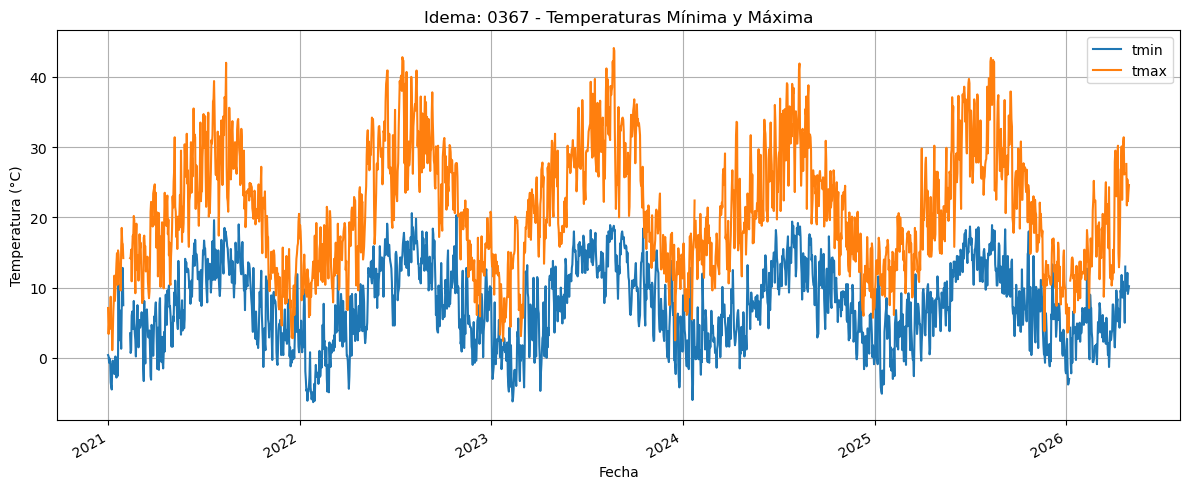

In [61]:
ax = data_9069C.sort_values("fecha").plot(x="fecha", y=["tmin", "tmax"], kind="line", figsize=(12,5))
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.set_title(f"Idema: {station_id} - Temperaturas Mínima y Máxima")
ax.grid(True)
plt.tight_layout()
plt.show()